## Capstone Project: Voice Cloning comparison on Open source and Industry model Comparison 
Generates sample voice data for three speakers, runs TTS/VTS inference, and compares industry voice cloning models

In [ ]:
!pip install TTS
!pip install noisereduce
!pip install pandas
!pip install librosa
!pip install seaborn
!pip install speechbrain torchaudio # To analyse voice cloning quality


## Data preview (Audio files and speakers Preview)


In [ ]:
import os
import pandas as pd
from pathlib import Path
import librosa

DATA_DIR = Path('data')
file_paths = []
speakers = []
durations = []

for root, dirs, files in os.walk(DATA_DIR):
    for file in files:
        if file.endswith(".wav"):
            path = os.path.join(root, file)
            y, sr = librosa.load(path, sr=16000)
            file_paths.append(path)
            speakers.append(os.path.basename(root))
            durations.append(len(y)/sr)

df = pd.DataFrame({"path": file_paths, "speaker": speakers, "duration": durations})
print("Dataset preview:")
df.head()
print("\nTotal speakers:", df['speaker'].nunique())
print("Total audio files:", len(df))


## Exploratory Data Analysis

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Distribution of audio duration
plt.figure(figsize=(8,5))
sns.histplot(df['duration'], bins=10)
plt.title("Distribution of Audio Durations")
plt.xlabel("Seconds")
plt.ylabel("Count")
plt.show()

# Speaker distribution
plt.figure(figsize=(8,4))
sns.countplot(y='speaker', data=df, order=df['speaker'].value_counts().index)
plt.title("Number of Samples per Speaker")
plt.show()


## Feature Extraction & Baseline Speaker Classification

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score


def extract_mfcc(path, n_mfcc=13):
    y, sr = librosa.load(path, sr=16000)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    return np.mean(mfcc.T, axis=0)

X = np.array([extract_mfcc(p) for p in df['path']])
y = df['speaker']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Baseline classifier
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, stratify=y, random_state=42)
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print("Baseline Accuracy:", accuracy_score(y_test, y_pred))
print("Baseline F1-score:", f1_score(y_test, y_pred, average='weighted'))


## Model Inference Placeholders

In [ ]:
#Testing TTS with simple model for voice cloning

from TTS.api import TTS

tts = TTS("tts_models/multilingual/multi-dataset/your_tts")
tts.tts_to_file(
    text="This Begins a New Practice This begins a series of weekly notes of Knowledge from Gurudev Sri Sri Ravi Shankar. Beyond an event is Knowledge. Beyond an object is Infinity. Beyond a person is Love. Knowledge is beyond events. Every event colours your awareness in some way. ",
    speaker_wav="data/Sample_voice5/p330_002.wav",
    file_path="data/Sample_voice5/results/your_tts_p330_002_out.wav",
    language="en")

## Analyzing voice cloning quality Open source model your_tts

In [ ]:
#Voice cloning for your_tts
import os
import glob
import torch
import torchaudio
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from speechbrain.pretrained import EncoderClassifier
import logging
logging.getLogger("speechbrain.utils.parameter_transfer").setLevel(logging.WARNING)
logging.getLogger("speechbrain.dataio.encoder").setLevel(logging.WARNING)
logging.getLogger("speechbrain.utils.fetching").setLevel(logging.WARNING)
logging.getLogger("speechbrain.utils.checkpoints").setLevel(logging.WARNING)
logging.getLogger("speechbrain.utils.parameter_transfer").setLevel(logging.WARNING)
logging.getLogger("speechbrain.dataio.encoder").setLevel(logging.WARNING)


logging.basicConfig(level=logging.WARNING)

# --------------------------
# Load SpeechBrain ECAPA-TDNN
# --------------------------
spk_model = EncoderClassifier.from_hparams(
    source="speechbrain/spkrec-ecapa-voxceleb",
    savedir="pretrained_models/spkrec-ecapa"
)

# --------------------------
# Settings
# --------------------------
num_voices = 3
pages = ["Page1", "Page2", "Page3"]
model_name = "your_tts"  # update if using multiple models
results_list = []

# --------------------------
# Loop through voices & pages
# --------------------------
for v in range(1, num_voices + 1):
    voice_dir = f"data/Sample_voice{v}"
    results_dir = os.path.join(voice_dir, "results")
    
    # Find original voice ending with _001.wav
    original_files = glob.glob(os.path.join(voice_dir, "*.wav"))
    if not original_files:
        print(f" No original voice found in {voice_dir}, skipping...")
        continue
    original_wav = original_files[0]
    
    # Load original audio
    signal, fs = torchaudio.load(original_wav)
    org_emb = spk_model.encode_batch(signal)
    org_emb_1d = org_emb.mean(dim=[0, 2])
    if org_emb.dim() > 1:
        org_emb = org_emb.mean(dim=0)  # reduce to 1D vector
    
    for page in pages:
        cloned_file = os.path.join(
            results_dir,
            f"{os.path.splitext(os.path.basename(original_wav))[0]}_{page}_{model_name}.wav"
        )
        print(cloned_file)
        if not os.path.exists(cloned_file):
            print(f" Cloned file not found: {cloned_file}, skipping...")
            continue
        
        # Load cloned audio
        cloned_signal, _ = torchaudio.load(cloned_file)
        cloned_emb = spk_model.encode_batch(cloned_signal)
        cloned_emb_1d = cloned_emb.mean(dim=[0, 2])
        if cloned_emb.dim() > 1:
            cloned_emb = cloned_emb.mean(dim=0)
        
        # Cosine similarity
        similarity = torch.nn.functional.cosine_similarity(
            org_emb_1d.unsqueeze(0),
            cloned_emb_1d.unsqueeze(0),
            dim=1).item()
        
        results_list.append({
            "Voice": f"Sample_voice{v}",
            "Page": page,
            "Original File": original_wav,
            "Cloned File": cloned_file,
            "Cosine Similarity": round(similarity, 4)
        })

your_tts_df = pd.DataFrame(results_list)

## Analytics and comparison between on Voice cloning quality for each voice samples

In [ ]:
%matplotlib inline
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --------------------------
# Quality categorization
# --------------------------
def cloning_quality(sim):
    if sim >= 0.85:
        return "Excellent"
    elif sim >= 0.7:
        return "Moderate"
    else:
        return "Poor"

your_tts_df["Quality"] = your_tts_df["Cosine Similarity"].apply(cloning_quality)
quality_colors = {"Excellent": "green", "Moderate": "orange", "Poor": "red"}

# --------------------------
# Chart 1: Per Page with Quality Dots
# --------------------------
plt.figure(figsize=(12, 5))
sns.barplot(
    data=your_tts_df,
    x="Page",
    y="Cosine Similarity",
    hue="Voice",
    palette="tab10"
)

for i, row in your_tts_df.iterrows():
    plt.scatter(
        row["Page"],
        row["Cosine Similarity"],
        color=quality_colors[row["Quality"]],
        s=100,
        edgecolor="black",
        zorder=5
    )
    plt.text(
        row["Page"],
        row["Cosine Similarity"] + 0.01,
        f"{row['Cosine Similarity']:.2f}",
        ha="center", va="bottom", fontsize=8
    )

plt.title("Voice Cloning Similarity per Page with Quality Indicator")
plt.ylim(0, 1)
plt.ylabel("Cosine Similarity (1 = identical)")
plt.xlabel("Text/Page")
plt.legend(title="Voice")
plt.tight_layout()
plt.savefig("voice_similarity_per_page.png", dpi=300, bbox_inches="tight")
plt.show(block=True)

## Multimodel comparisons with given sample voices

In [ ]:
# Cloned voice wav files are generated under data/sample_voice<number>/results/<file_name>_<model_name>_<page_name>.wav
%matplotlib inline
import os
import glob
import torch
import torchaudio
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from TTS.api import TTS
from speechbrain.pretrained import EncoderClassifier
import logging
logging.getLogger("speechbrain.utils.parameter_transfer").setLevel(logging.WARNING)
logging.getLogger("speechbrain.dataio.encoder").setLevel(logging.WARNING)
logging.getLogger("speechbrain.utils.fetching").setLevel(logging.WARNING)

logging.basicConfig(level=logging.WARNING)

# --------------------------
# Settings
# --------------------------
num_voices = 5
pages = ["Page1", "Page2", "Page3"]
texts = {
    "Page1" : "This Begins a New Practice This begins a series of weekly notes of Knowledge from Gurudev Sri Sri Ravi Shankar. Beyond an event is Knowledge. Beyond an object is Infinity. Beyond a person is Love. Knowledge is beyond events. Every event colours your awareness in some way. ",
    "Page2" : "Close to the Master If you’re not feeling close to the Master, it’s because of you – because of your mind, your ego concepts. Just being on the levels of formal and informal communication cannot make you feel close. 'How are you?' 'Where are you going?' 'How have you been?'",
    "Page3" : "Prarabdha Karma and Sanchita Karma Some karma can be changed and some cannot. When you prepare a dessert, if sugar or ghee is too little, you can add more. If some other ingredient is too much, it can all be adjusted and repaired. But once it is cooked, it cannot be reversed. Milk can become sweet yoghurt or sour yoghurt, and sour yoghurt can be sweetened." 

}

# Define TTS models
tts_models = [
    "tts_models/multilingual/multi-dataset/your_tts",
    #"tts_models/multilingual/multi-dataset/xtts_v2"
    "tts_models/en/ljspeech/vits"
]

# --------------------------
# Load Speaker Embedding Model
# --------------------------
spk_model = EncoderClassifier.from_hparams(
    source="speechbrain/spkrec-ecapa-voxceleb",
    savedir="pretrained_models/spkrec-ecapa"
)

# --------------------------
# Run TTS and Compute Similarity
# --------------------------
results_list = []

for v in range(1, num_voices + 1):
    voice_dir = f"data/Sample_voice{v}"
    results_dir = os.path.join(voice_dir, "results")
    os.makedirs(results_dir, exist_ok=True)

    # Find original voice file ending with _001.wav
    original_files = glob.glob(os.path.join(voice_dir, "*_001.wav"))
    if not original_files:
        print(f"No original voice found in {voice_dir}, skipping...")
        continue
    original_wav = original_files[0]

    # Load original audio
    signal, fs = torchaudio.load(original_wav)
    org_emb = spk_model.encode_batch(signal)
    if org_emb.dim() > 1:
        org_emb = org_emb.mean(dim=[0, 2])  # 1D vector

    for model_id in tts_models:
        tts_model_name = model_id.split("/")[-1]
        tts = TTS(model_id)

        for page_name in pages:
            # Output file
            output_file = os.path.join(
                results_dir,
                f"{os.path.splitext(os.path.basename(original_wav))[0]}_{page_name}_{tts_model_name}.wav"
            )

            # Generate TTS if file does not exist
            if not os.path.exists(output_file):
                if "multilingual" in model_id:
                    tts.tts_to_file(
                        text=texts[page_name],
                        speaker_wav=original_wav,
                        file_path=output_file,
                        language="en")
                elif "xtts_v2" in model_id:
                    import TTS.tts.configs.xtts_config
                    torch.serialization.safe_globals([TTS.tts.configs.xtts_config.XttsConfig])
                    tts.tts_to_file(
                        text=texts[page_name],
                        speaker_wav=original_wav,
                        file_path=output_file,
                        weights_only=True,
                        language="en")

                else:
                    tts.tts_to_file(
                        text=texts[page_name],
                        speaker_wav=original_wav,
                        file_path=output_file)

            # Load cloned audio
            cloned_signal, _ = torchaudio.load(output_file)
            cloned_emb = spk_model.encode_batch(cloned_signal)
            if cloned_emb.dim() > 1:
                cloned_emb = cloned_emb.mean(dim=[0, 2])

            # Cosine similarity
            similarity = torch.nn.functional.cosine_similarity(
                org_emb.unsqueeze(0),
                cloned_emb.unsqueeze(0),
                dim=1).item()

            results_list.append({
                "Voice": f"Sample_voice{v}",
                "Page": page_name,
                "Model": tts_model_name,
                "Original File": original_wav,
                "Cloned File": output_file,
                "Cosine Similarity": round(similarity, 4)
            })

# --------------------------
# Save results to CSV
# --------------------------
df = pd.DataFrame(results_list)
df.to_csv("multi_model_voice_similarity.csv", index=False)
print(" Multi-model similarity results saved to CSV")
print(df.head())


## Voice Cloning Quality analysis and comparisons - Multimodel

In [ ]:
#Voice Cloning Similarity Heatmap (Models × Pages)
plt.figure(figsize=(10, 6))
pivot_df = df.pivot_table(
    index="Model", columns="Page", values="Cosine Similarity", aggfunc="mean"
)
sns.heatmap(pivot_df, annot=True, cmap="YlGnBu", vmin=0, vmax=1, cbar=True, linewidths=0.5)
plt.title("Voice Cloning Similarity Heatmap (Models × Pages)", fontsize=14)
plt.ylabel("TTS Model")
plt.xlabel("Text/Page")
plt.tight_layout()
plt.show()

In [ ]:
#Voice Cloning Quality Classification per Model
def cloning_quality(sim):
    if sim >= 0.85:
        return "Excellent"
    elif sim >= 0.7:
        return "Moderate"
    else:
        return "Poor"

df["Quality"] = df["Cosine Similarity"].apply(cloning_quality)

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df,
    x="Model",
    y="Cosine Similarity",
    hue="Quality",
    style="Page",
    size="Cosine Similarity",
    sizes=(50, 200),
    palette={"Excellent": "green", "Moderate": "orange", "Poor": "red"}
)
plt.title("Voice Cloning Quality Classification per Model", fontsize=14)
plt.ylim(0, 1)
plt.ylabel("Cosine Similarity (1 = identical)")
plt.xlabel("TTS Model")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [ ]:
#Voice Cloning Quality per Voice and Model
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Assume df is already created
# Columns: ["Voice", "Page", "Model", "Cosine Similarity"]

# --------------------------
# Add Quality Labels
# --------------------------
def cloning_quality(sim):
    if sim >= 0.85:
        return "Excellent"
    elif sim >= 0.7:
        return "Moderate"
    else:
        return "Poor"

df["Quality"] = df["Cosine Similarity"].apply(cloning_quality)

# --------------------------
# 1. Grouped Bar Plot per Voice × Model
# --------------------------
plt.figure(figsize=(14, 6))
sns.barplot(
    data=df,
    x="Voice",
    y="Cosine Similarity",
    hue="Model",
    errorbar=None,
    palette="tab10"
)

# Overlay quality dots
quality_colors = {"Excellent": "green", "Moderate": "orange", "Poor": "red"}
for i, row in df.iterrows():
    plt.scatter(
        x=row["Voice"],
        y=row["Cosine Similarity"],
        color=quality_colors[row["Quality"]],
        s=100,
        edgecolor="black",
        zorder=5
    )

plt.title("Voice Cloning Quality per Voice and Model", fontsize=14)
plt.ylim(0, 1)
plt.ylabel("Cosine Similarity (1 = identical)")
plt.xlabel("Reference Voice")
plt.legend(title="TTS Model", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("voice_quality_barplot.png", dpi=300)
plt.show()

# --------------------------
# 2. Heatmap: Voices × Models
# --------------------------
plt.figure(figsize=(10, 6))
pivot_df = df.pivot_table(
    index="Voice", columns="Model", values="Cosine Similarity", aggfunc="mean"
)
sns.heatmap(
    pivot_df, annot=True, cmap="RdYlGn", vmin=0, vmax=1, linewidths=0.5
)

plt.title("Average Voice Cloning Quality (Voices × Models)", fontsize=14)
plt.ylabel("Reference Voice")
plt.xlabel("TTS Model")
plt.tight_layout()
plt.savefig("voice_quality_heatmap.png", dpi=300)
plt.show()


## Voice cloning comparision between open source vs industry models

In [ ]:
import os, time
import torch
import torchaudio
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from speechbrain.pretrained import EncoderClassifier
from TTS.api import TTS
import warnings
warnings.filterwarnings("ignore")

# --------------------------
# Setup models
# --------------------------
models = {
    "your_tts": "tts_models/multilingual/multi-dataset/your_tts",
    "vits": "tts_models/en/ljspeech/vits"
}

# Speaker verification model
spk_model = EncoderClassifier.from_hparams(source="speechbrain/spkrec-ecapa-voxceleb")

# Pages (texts for synthesis)
texts = {
    "Page1": "This is the first test page for benchmarking voice cloning quality.",
    "Page2": "The second page is slightly longer to test runtime performance.",
    "Page3": "Finally, this is page three with another variation in sentence structure."
}

# Data paths
base_dir = "Data"
voices = ["Sample_voicep225","Sample_voicep226","Sample_voicep227","Sample_voicep228","Sample_voicep229","Sample_voicep230",
          "Sample_voicep231","Sample_voicep232","Sample_voicep233","Sample_voicep234","Sample_voicep236","Sample_voicep237",
          "Sample_voicep238","Sample_voicep239","Sample_voicep240","Sample_voicep241","Sample_voicep243","Sample_voicep244",
          "Sample_voicep245","Sample_voicep340"]  # extend for multiple voices

results = []

# --------------------------
# Helper: compute embedding
# --------------------------
def get_embedding(wav_path):
    signal, fs = torchaudio.load(wav_path)
    emb = spk_model.encode_batch(signal).squeeze(0)
    return emb.mean(dim=0) if emb.ndim > 1 else emb

# --------------------------
# Run experiments
# --------------------------
for model_name, model_id in models.items():
    tts = TTS(model_id)

    for voice in voices:
        voice_dir = os.path.join(base_dir, voice)
        ref_files = [f for f in os.listdir(voice_dir) if f.endswith(".wav")]

        # Case 1: Single reference voice
        single_ref = os.path.join(voice_dir, ref_files[0])
        single_emb = get_embedding(single_ref)

        # Case 2: Multiple reference voices (averaged embeddings)
        multi_embs = [get_embedding(os.path.join(voice_dir, f)) for f in ref_files]
        multi_emb = torch.stack(multi_embs).mean(dim=0)

        for case, emb in [("Single", single_emb), ("Multiple", multi_emb)]:
            for page, text in texts.items():
                out_path = os.path.join(
                    voice_dir, "results", f"{os.path.splitext(ref_files[0])[0]}_{model_name}_{page}_{case}.wav"
                )
                os.makedirs(os.path.dirname(out_path), exist_ok=True)

                start = time.time()
                if "multilingual" in model_id:
                    tts.tts_to_file(text=text, speaker_wav=single_ref, file_path=out_path,language = "en")
                else:
                    tts.tts_to_file(text=text, speaker_wav=single_ref, file_path=out_path)
                runtime = time.time() - start

                # Evaluate similarity
                cloned_emb = get_embedding(out_path)
                sim = torch.nn.functional.cosine_similarity(single_emb.unsqueeze(0), cloned_emb.unsqueeze(0)).item()

                results.append({
                    "Model": model_name,
                    "Voice": voice,
                    "Case": case,
                    "Page": page,
                    "Cosine Similarity": round(sim, 4),
                    "Runtime (s)": round(runtime, 2)
                })

# --------------------------
# Save and plot results
# --------------------------
df = pd.DataFrame(results)
df.to_csv("comparison_yourtts_vits.csv", index=False)
print(df)


In [ ]:
%matplotlib inline

print(results)
df.to_csv("comparison_yourtts_vits.csv", index=False)
print(df)

# Plot
sns.catplot(
    data=df, x="Page", y="Cosine Similarity",
    hue="Case", col="Model", kind="bar", height=5, aspect=1
)
plt.show(block=True)

sns.catplot(
    data=df, x="Page", y="Runtime (s)",
    hue="Case", col="Model", kind="bar", height=5, aspect=1
)
plt.show(block=True)

## Extenstion to my previous open source model comparisons
#### Adding industry models vs opensource models

In [ ]:
!pip install elevenlabs
!pip install openai

## Testing Eleven labs create and synthsis voice based on given voice sample

In [ ]:

import os
import glob
import requests
import time

os.environ["ELEVENLABS_API_KEY"]= ""
ELEVEN_API_KEY = os.getenv("ELEVENLABS_API_KEY")  # set this in your environment
if not ELEVEN_API_KEY:
    raise RuntimeError("Set ELEVENLABS_API_KEY env var")

# Example texts (your Page1/2/3)
texts = {
    "Page1": "This Begins a New Practice ...",
    "Page2": "Close to the Master ...",
    "Page3": "Prarabdha Karma and Sanchita Karma ..."
}

HEADERS = {"xi-api-key": ""}

def create_ivc_voice(name: str, file_paths: list[str], remove_background_noise: bool = False, description: str | None = None):
    """
    Create an instant voice clone (IVC) using ElevenLabs REST API.
    Returns (voice_id, requires_verification)
    Docs: POST https://api.elevenlabs.io/v1/voices/add
    """
    url = "https://api.elevenlabs.io/v1/voices/add"
    # Build multipart list of files: ('files', (filename, fileobj, 'audio/wav'))
    files = []
    fobjs = []
    try:
        for fp in file_paths:
            f = open(fp, "rb")
            fobjs.append(f)
            files.append(("files", (os.path.basename(fp), f, "audio/wav")))
        payload = {
            "name": name,
            "remove_background_noise": str(remove_background_noise).lower()
        }
        if description:
            payload["description"] = description

        resp = requests.post(url, headers=HEADERS, data=payload, files=files, timeout=120)
    finally:
        # close files
        for f in fobjs:
            try:
                f.close()
            except:
                pass

    resp.raise_for_status()
    j = resp.json()
    # Example response: {"voice_id":"...","requires_verification": false}
    return j.get("voice_id"), j.get("requires_verification", False)


def synthesize_voice(voice_id: str, text: str, out_path: str, model_id: str = "eleven_multilingual_v2", output_format: str = "mp3_44100_128"):
    """
    Synthesize text using created voice_id.
    Endpoint: POST https://api.elevenlabs.io/v1/text-to-speech/{voice_id}
    Writes audio bytes to out_path (streamed).
    """
    url = f"https://api.elevenlabs.io/v1/text-to-speech/{voice_id}"
    payload = {
        "text": text,
        "model_id": model_id
    }
    params = {"output_format": output_format}
    headers = {**HEADERS, "Content-Type": "application/json"}
    # stream=True so we can write chunk-by-chunk
    r = requests.post(url, json=payload, headers=headers, params=params, stream=True, timeout=120)
    r.raise_for_status()
    with open(out_path, "wb") as fh:
        for chunk in r.iter_content(chunk_size=4096):
            if chunk:
                fh.write(chunk)
    return out_path


# -------------------------------------------------------
# Example: iterate speaker folders, build IVC from all .wav, then synth per page
# -------------------------------------------------------
base = "data"  # your data folder
voice_dirs = sorted(glob.glob(os.path.join(base, "Sample_voice*")))

for vdir in voice_dirs:
    wavs = sorted(glob.glob(os.path.join(vdir, "*.wav")))
    if not wavs:
        print("no wavs in", vdir); continue

    speaker_name = os.path.basename(vdir)
    print(f"\nCreating IVC for {speaker_name} using {len(wavs)} sample files...")

    # Now synthesize Page1/Page2/Page3 using this voice_id
    results_dir = os.path.join(vdir, "results")
    voice_id="GbwKPk0IHO92spjr3gwT"
    os.makedirs(results_dir, exist_ok=True)
    for page_name, page_text in texts.items():
        out_name = f"{speaker_name}_elevenlabs_{page_name}.mp3"  # mp3 default; choose extension accordingly
        out_path = os.path.join(results_dir, out_name)
        try:
            synthesize_voice(voice_id, page_text, out_path)
            print("Saved:", out_path)
        except Exception as e:
            print("Synthesis failed:", e)


## Visualizations

✅ Results saved to benchmark_results_full.csv
         Speaker       Model   Page  Similarity  Naturalness
0  Sample_voice2    your_tts  Page2    0.444390     4.732391
1  Sample_voice2  elevenlabs  Page3    0.132088     4.466100
2  Sample_voice2  elevenlabs  Page2    0.096095     3.092260
3  Sample_voice2    your_tts  Page3    0.447386     3.788088
4  Sample_voice2    your_tts  Page1    0.437188     3.845099


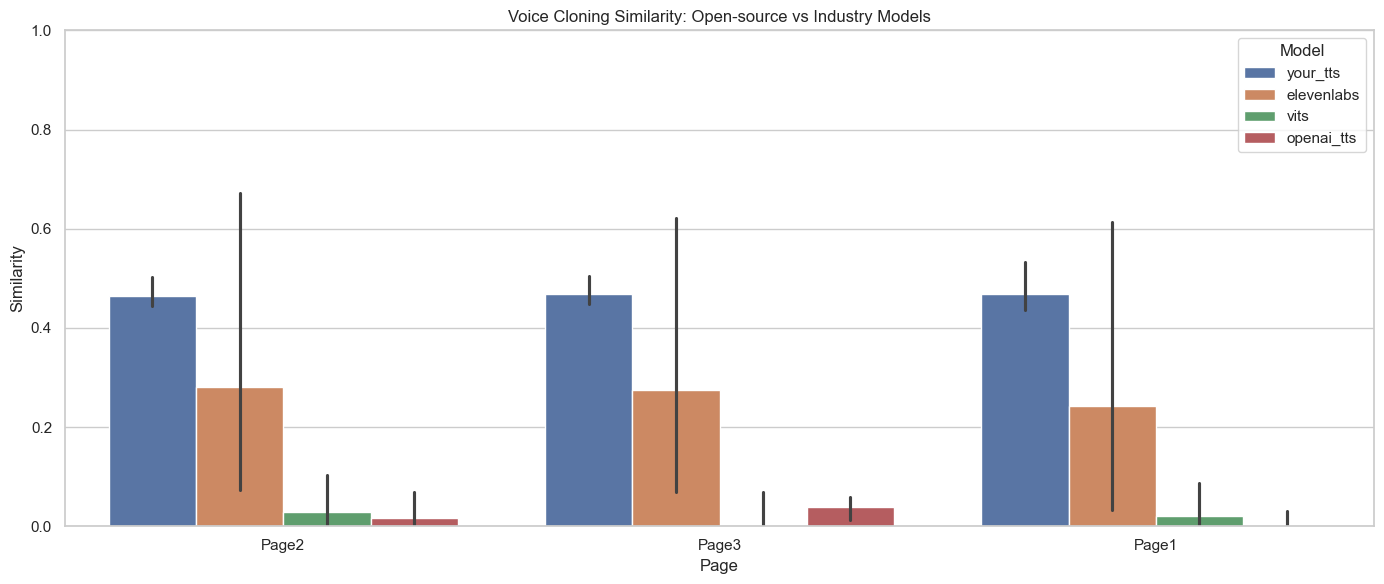

In [61]:
df.to_csv("benchmark_results_full.csv", index=False)
print("Results saved to benchmark_results_full.csv")
print(df.head())

sns.set(style="whitegrid")

# Voice Cloning Quality
plt.figure(figsize=(14,6))
sns.barplot(data=df, x="Page", y="Similarity", hue="Model")
plt.title("Voice Cloning Similarity: Open-source vs Industry Models")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## Voice Cloning Benchmark 

### Multi-sample per speaker, Open-source + Industry

In [9]:
%matplotlib inline
import os
import glob
import time
import numpy as np
import pandas as pd
import torch
import torchaudio
import matplotlib.pyplot as plt
import seaborn as sns
from speechbrain.pretrained import EncoderClassifier
from TTS.api import TTS
import requests
import logging

# Suppress warnings from speechbrain
logging.getLogger("speechbrain.utils.parameter_transfer").setLevel(logging.WARNING)
logging.getLogger("speechbrain.dataio.encoder").setLevel(logging.WARNING)
logging.getLogger("speechbrain.utils.fetching").setLevel(logging.WARNING)
logging.getLogger("speechbrain.utils.checkpoints").setLevel(logging.WARNING)

# ----------------------
# CONFIG
# ----------------------
DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

texts = {
    "Page1": "This Begins a New Practice This begins a series of weekly notes of Knowledge from Gurudev Sri Sri Ravi Shankar...",
    "Page2": "Close to the Master If you’re not feeling close to the Master, it’s because of you – because of your mind, your ego concepts...",
    "Page3": "Prarabdha Karma and Sanchita Karma Some karma can be changed and some cannot..."
}

open_source_models = {
    "your_tts": "tts_models/multilingual/multi-dataset/your_tts",
    "vits": "tts_models/en/ljspeech/vits"
}
ELEVENLABS_VOICE_ID="" #p226
#WypIqw2CS8UDT8xmTkdC #p225

industry_models = ["openai_tts", "elevenlabs"]
# ----------------------
# API Keys (set your own!)
# ----------------------
ELEVENLABS_API_KEY = os.getenv("ELEVENLABS_API_KEY", "")
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY", "")

HEADERS = {"xi-api-key": ELEVENLABS_API_KEY}

# ----------------------
# Speaker Embeddings
# ----------------------
spk_model = EncoderClassifier.from_hparams(
    source="speechbrain/spkrec-ecapa-voxceleb",
    run_opts={"device": "cpu"}
)

def get_embedding(path):
    signal, fs = torchaudio.load(path)
    emb = spk_model.encode_batch(signal)
    return emb.mean(dim=1).squeeze(0)

# ----------------------
# OpenAI TTS
# ----------------------
import openai
openai.api_key = OPENAI_API_KEY

def generate_openai_tts(text, output_file):
    response = openai.audio.speech.create(
        model="gpt-4o-mini-tts",
        voice="alloy",
        input=text
    )
    audio_data = response.read()  # bytes
    with open(output_file, "wb") as f:
        f.write(audio_data)

# ----------------------
# ElevenLabs REST API
# ----------------------
def create_ivc_voice(name: str, file_paths: list[str], description: str = None):
    """
    Create an instant voice clone (IVC) using ElevenLabs REST API.
    """
    url = "https://api.elevenlabs.io/v1/voices/add"
    files = []
    fobjs = []
    try:
        for fp in file_paths:
            f = open(fp, "rb")
            fobjs.append(f)
            files.append(("files", (os.path.basename(fp), f, "audio/wav")))
        payload = {"name": name}
        if description:
            payload["description"] = description
        resp = requests.post(url, headers=HEADERS, data=payload, files=files, timeout=120)
    finally:
        for f in fobjs:
            f.close()
    resp.raise_for_status()
    return resp.json().get("voice_id")

def synthesize_voice(voice_id: str, text: str, out_path: str, model_id: str = "eleven_multilingual_v2", output_format: str = "mp3_44100_128"):
    """
    Synthesize text using created voice_id.
    Endpoint: POST https://api.elevenlabs.io/v1/text-to-speech/{voice_id}
    Writes audio bytes to out_path (streamed).
    """
    url = f"https://api.elevenlabs.io/v1/text-to-speech/{voice_id}"
    payload = {
        "text": text,
        "model_id": model_id
    }
    params = {"output_format": output_format}
    headers = {**HEADERS, "Content-Type": "application/json"}
    # stream=True so we can write chunk-by-chunk
    r = requests.post(url, json=payload, headers=headers, params=params, stream=True, timeout=120)
    r.raise_for_status()
    with open(out_path, "wb") as fh:
        for chunk in r.iter_content(chunk_size=4096):
            if chunk:
                fh.write(chunk)
    return out_path

# ----------------------
# Benchmark function
# ----------------------
def benchmark_model(model_name, voice_dirs, texts):
    results = []
    for voice_dir in voice_dirs:
        speaker_files = glob.glob(os.path.join(voice_dir, "*.wav"))
        if not speaker_files:
            continue

        base_name = os.path.basename(voice_dir)
        out_dir = os.path.join(voice_dir, "results")
        os.makedirs(out_dir, exist_ok=True)

        # For open-source: multi-sample embedding
        if model_name in open_source_models:
            ref_embs = [get_embedding(f) for f in speaker_files]
            org_emb = torch.stack(ref_embs).mean(dim=0)
            ref_wav = speaker_files[0]
        else:
            org_emb = None
            ref_wav = None

        for page, text in texts.items():
            out_file = os.path.join(out_dir, f"{base_name}_{model_name}_{page}.wav")
            start_time = time.time()
            similarity = None
            cost = 0.0

            try:
                # ----------------------
                # Open-source TTS (your_tts and vts)
                # ----------------------
                if model_name in open_source_models:
                    tts = TTS(open_source_models[model_name])
                    if "multilingual" in open_source_models[model_name]:
                        tts.tts_to_file(text=text, file_path=out_file, speaker_wav=ref_wav, language="en")
                    else:
                        tts.tts_to_file(text=text, file_path=out_file, speaker_wav=ref_wav)

                # ----------------------
                # OpenAI TTS
                # ----------------------
                elif model_name == "openai_tts":
                    generate_openai_tts(text, out_file)
                    cost = 0.15  # USD/min (approx)

                # ----------------------
                # ElevenLabs TTS
                # ----------------------
                elif model_name == "elevenlabs":
                    # Use synthesis_model with pre-created voice_id
                    
                    try:
                        synthesize_voice(ELEVENLABS_VOICE_ID, text, out_file)
                        print("Eleven labs voice cloning Saved:", out_file)
                    except Exception as e:
                        print("Eleven labs Synthesis failed:", e)
                    cost = len(text) / 1000 * 0.03  # $0.03 per 1k chars

            except Exception as e:
                print(f"Error with {model_name}, {voice_dir}, {page}: {e}")

            elapsed = round(time.time() - start_time, 2)
            results.append({
                "Model": model_name,
                "Voice": base_name,
                "Page": page,
                "Time (s)": elapsed,
                "Cost USD": cost
            })
    return results

# ----------------------
# Run benchmark
# ----------------------
voice_dirs = sorted(glob.glob(os.path.join(DATA_DIR, "Sample_voice*")))
all_results = []


for model_name in list(open_source_models.keys()) + industry_models:
    all_results.extend(benchmark_model(model_name, voice_dirs, texts))

# Save results
voice_cloning_df = pd.DataFrame(all_results)
voice_cloning_df.to_csv("benchmark_results_multisample.csv", index=False)
print("Results saved to benchmark_results_multisample.csv")
print(voice_cloning_df.head())




/opt/anaconda3/envs/tts_env/lib/python3.10/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


 > tts_models/multilingual/multi-dataset/your_tts is already downloaded.
 > Using model: vits
 > Setting up Audio Processor...
 | > sample_rate:16000
 | > resample:False
 | > num_mels:80
 | > log_func:np.log10
 | > min_level_db:0
 | > frame_shift_ms:None
 | > frame_length_ms:None
 | > ref_level_db:None
 | > fft_size:1024
 | > power:None
 | > preemphasis:0.0
 | > griffin_lim_iters:None
 | > signal_norm:None
 | > symmetric_norm:None
 | > mel_fmin:0
 | > mel_fmax:None
 | > pitch_fmin:None
 | > pitch_fmax:None
 | > spec_gain:20.0
 | > stft_pad_mode:reflect
 | > max_norm:1.0
 | > clip_norm:True
 | > do_trim_silence:False
 | > trim_db:60
 | > do_sound_norm:False
 | > do_amp_to_db_linear:True
 | > do_amp_to_db_mel:True
 | > do_rms_norm:False
 | > db_level:None
 | > stats_path:None
 | > base:10
 | > hop_length:256
 | > win_length:1024
 > Model fully restored. 
 > Setting up Audio Processor...
 | > sample_rate:16000
 | > resample:False
 | > num_mels:64
 | > log_func:np.log10
 | > min_level_db:-

/opt/anaconda3/envs/tts_env/lib/python3.10/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


 > tts_models/en/ljspeech/vits is already downloaded.
 > Using model: vits
 > Setting up Audio Processor...
 | > sample_rate:22050
 | > resample:False
 | > num_mels:80
 | > log_func:np.log10
 | > min_level_db:0
 | > frame_shift_ms:None
 | > frame_length_ms:None
 | > ref_level_db:None
 | > fft_size:1024
 | > power:None
 | > preemphasis:0.0
 | > griffin_lim_iters:None
 | > signal_norm:None
 | > symmetric_norm:None
 | > mel_fmin:0
 | > mel_fmax:None
 | > pitch_fmin:None
 | > pitch_fmax:None
 | > spec_gain:20.0
 | > stft_pad_mode:reflect
 | > max_norm:1.0
 | > clip_norm:True
 | > do_trim_silence:False
 | > trim_db:60
 | > do_sound_norm:False
 | > do_amp_to_db_linear:True
 | > do_amp_to_db_mel:True
 | > do_rms_norm:False
 | > db_level:None
 | > stats_path:None
 | > base:10
 | > hop_length:256
 | > win_length:1024
 > Text splitted to sentences.
['This Begins a New Practice This begins a series of weekly notes of Knowledge from Gurudev Sri Sri Ravi Shankar...']
 > Processing time: 2.016684055

/opt/anaconda3/envs/tts_env/lib/python3.10/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


 > tts_models/en/ljspeech/vits is already downloaded.
 > Using model: vits
 > Setting up Audio Processor...
 | > sample_rate:22050
 | > resample:False
 | > num_mels:80
 | > log_func:np.log10
 | > min_level_db:0
 | > frame_shift_ms:None
 | > frame_length_ms:None
 | > ref_level_db:None
 | > fft_size:1024
 | > power:None
 | > preemphasis:0.0
 | > griffin_lim_iters:None
 | > signal_norm:None
 | > symmetric_norm:None
 | > mel_fmin:0
 | > mel_fmax:None
 | > pitch_fmin:None
 | > pitch_fmax:None
 | > spec_gain:20.0
 | > stft_pad_mode:reflect
 | > max_norm:1.0
 | > clip_norm:True
 | > do_trim_silence:False
 | > trim_db:60
 | > do_sound_norm:False
 | > do_amp_to_db_linear:True
 | > do_amp_to_db_mel:True
 | > do_rms_norm:False
 | > db_level:None
 | > stats_path:None
 | > base:10
 | > hop_length:256
 | > win_length:1024
 > Text splitted to sentences.
['This Begins a New Practice This begins a series of weekly notes of Knowledge from Gurudev Sri Sri Ravi Shankar...']
 > Processing time: 1.759454011

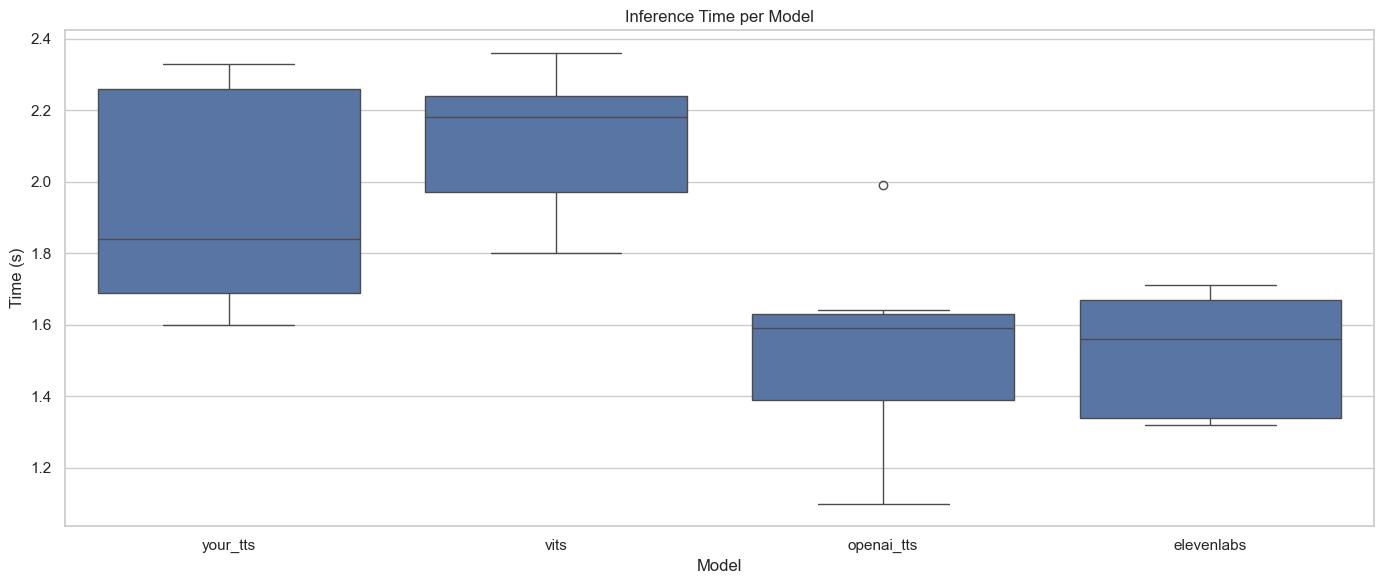

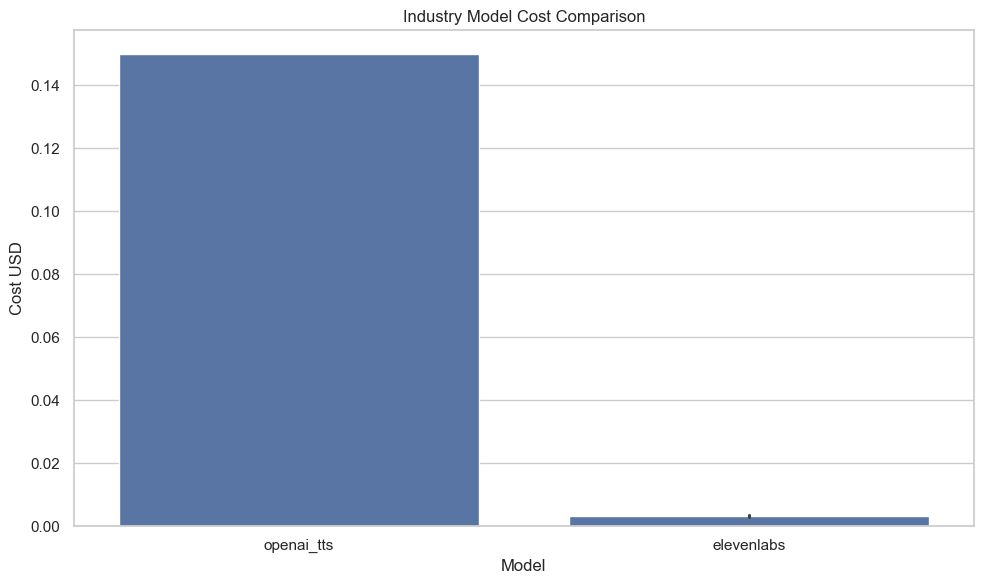

In [11]:
# ----------------------
# Visualizations
# ----------------------

sns.set(style="whitegrid")


# 2. Inference Time
plt.figure(figsize=(14,6))
sns.boxplot(data=voice_cloning_df, x="Model", y="Time (s)")
plt.title("Inference Time per Model")
plt.tight_layout()
plt.show(block=True)

# 3. Cost (Industry models)
plt.figure(figsize=(10,6))
subset = voice_cloning_df[voice_cloning_df["Cost USD"] > 0]
sns.barplot(data=subset, x="Model", y="Cost USD")
plt.title("Industry Model Cost Comparison")
plt.tight_layout()
plt.show(block=True)

/opt/anaconda3/envs/tts_env/lib/python3.10/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


Results saved to voice_cloning_quality_results.csv
         Speaker       Model   Page  Similarity  Naturalness
0  Sample_voice2    your_tts  Page2    0.444390     4.732391
1  Sample_voice2  elevenlabs  Page3    0.132088     4.466100
2  Sample_voice2  elevenlabs  Page2    0.096095     3.092260
3  Sample_voice2    your_tts  Page3    0.447386     3.788088
4  Sample_voice2    your_tts  Page1    0.437188     3.845099


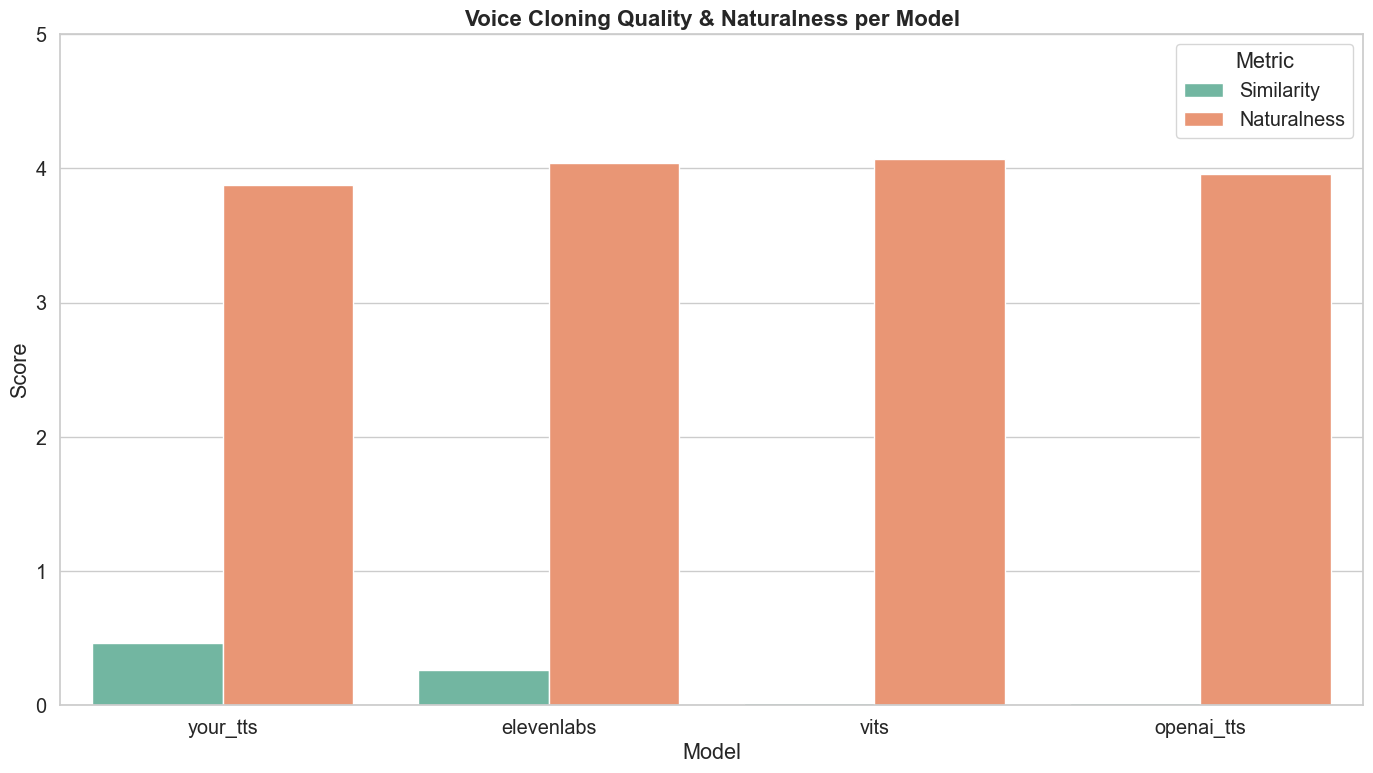

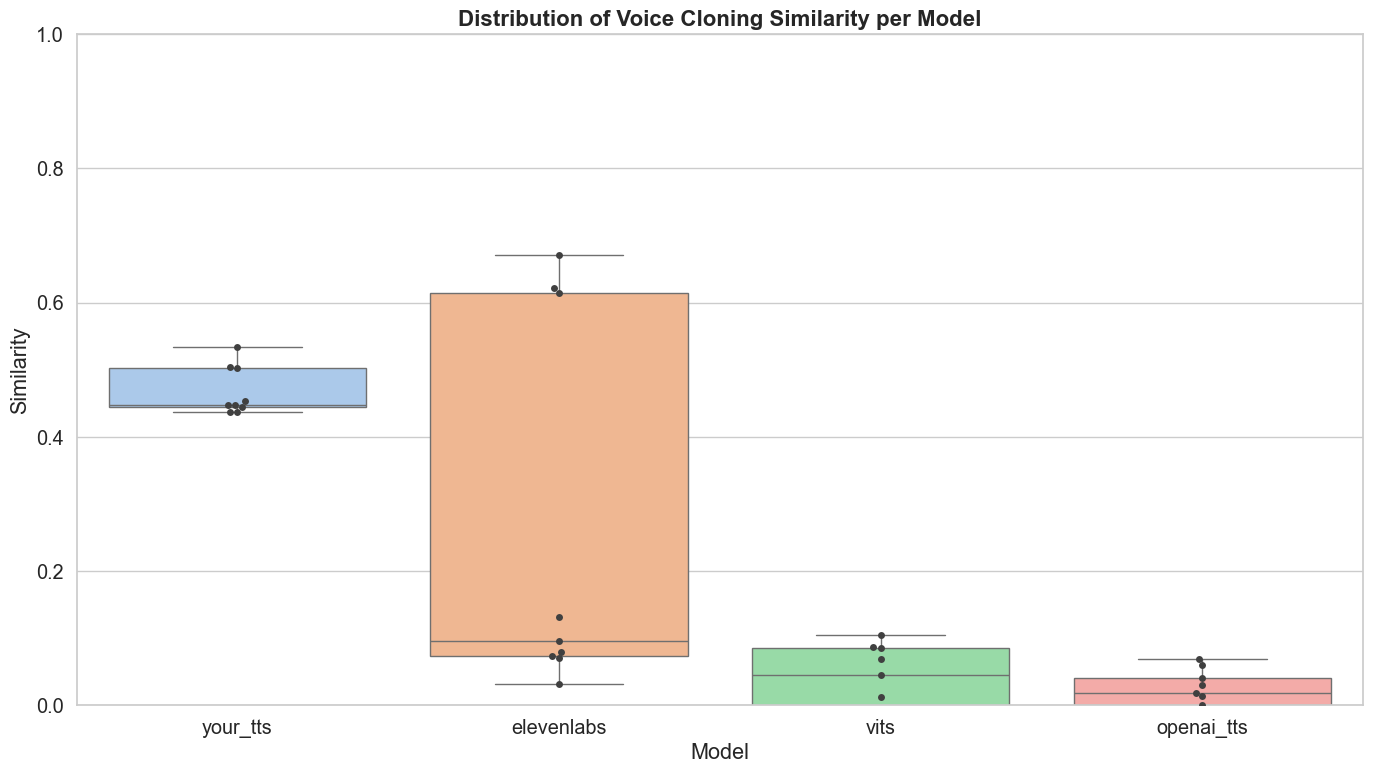

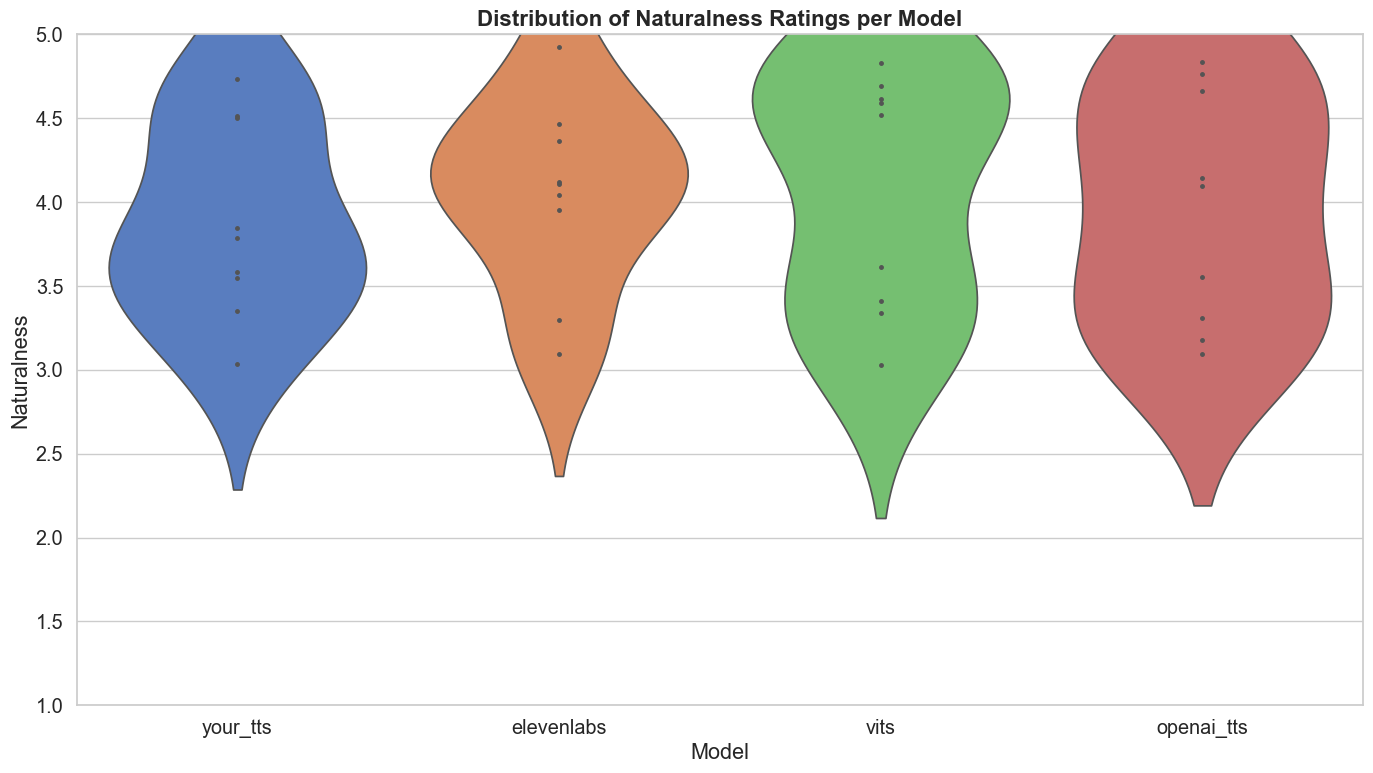

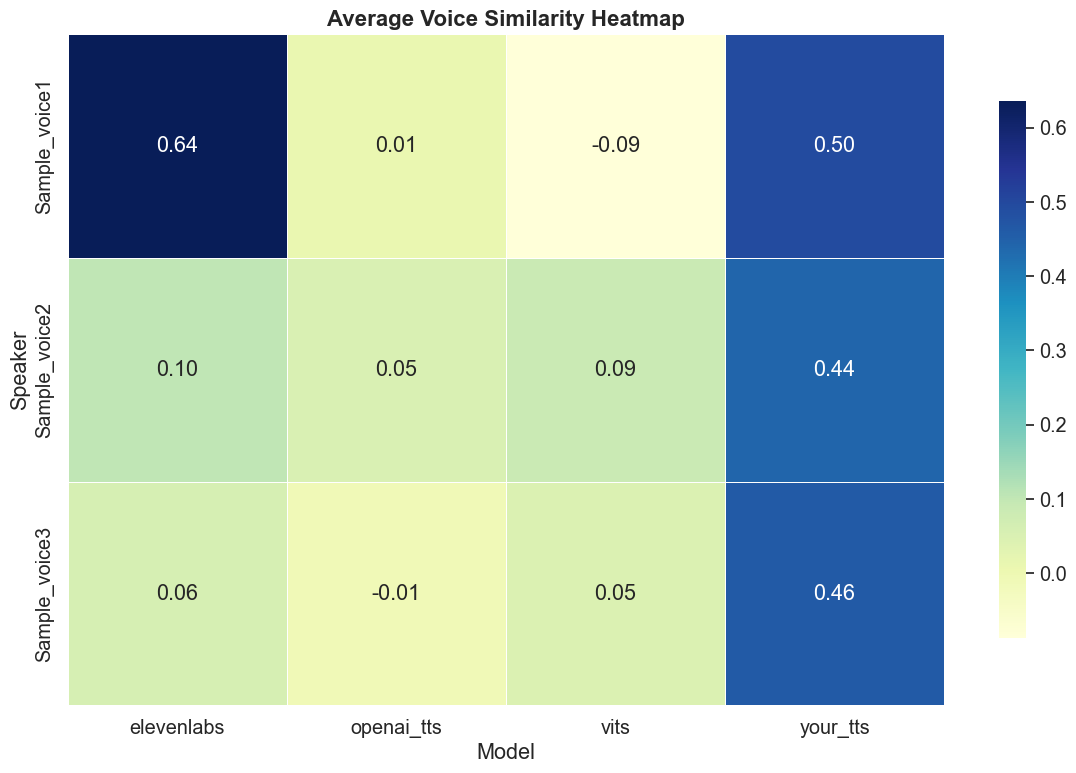

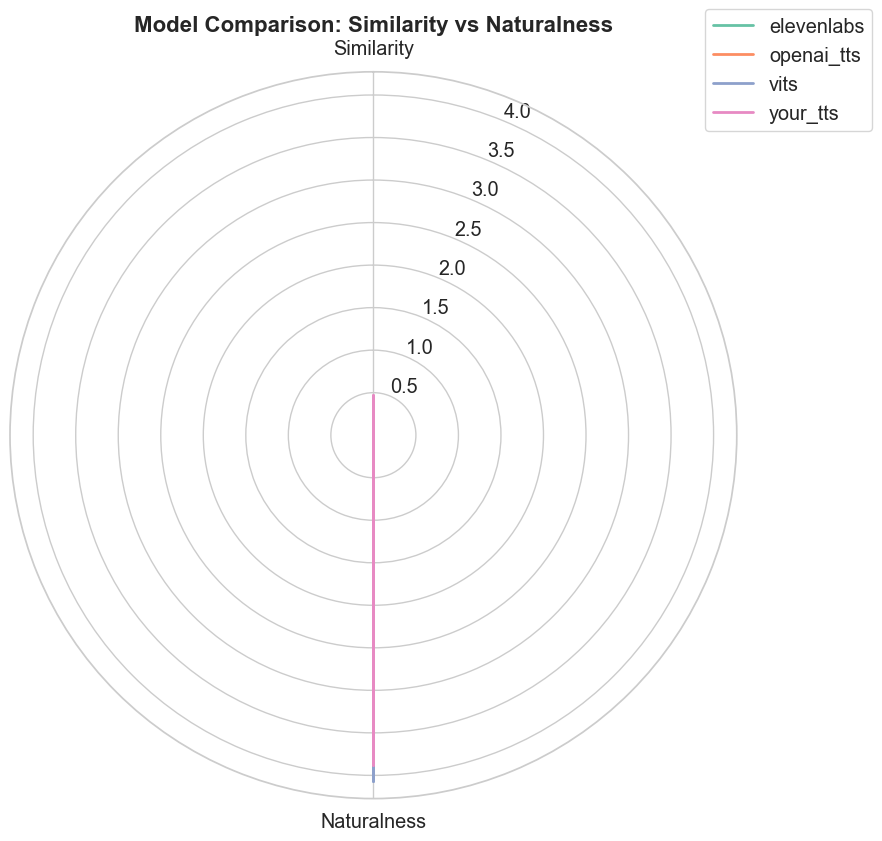

 All plots saved in: plots


In [55]:
# Voice Cloning Quality & Naturalness Evaluation (with PNG saving)

import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re

from speechbrain.pretrained import SpeakerRecognition

# ------------------------------
# Config
# ------------------------------
BASE_DIR = "data"
RESULTS_FILE = "voice_cloning_quality_results.csv"
PLOTS_DIR = "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

# Load Speaker Recognition model
verifier = SpeakerRecognition.from_hparams(
    source="speechbrain/spkrec-ecapa-voxceleb",
    savedir="pretrained_models/spkrec-ecapa-voxceleb"
)

# ------------------------------
# Helper Functions
# ------------------------------

def cosine_similarity(ref_file, gen_file):
    """Compute cosine similarity between reference and generated voice"""
    score, _ = verifier.verify_files(ref_file, gen_file)
    return float(score)


def evaluate_model_quality():
    results = []

    sample_dirs = glob.glob(os.path.join(BASE_DIR, "Sample_voice*"))
    for sample_dir in sample_dirs:
        speaker = os.path.basename(sample_dir)
        ref_files = glob.glob(os.path.join(sample_dir, "*.wav"))

        results_dir = os.path.join(sample_dir, "results")
        gen_files = glob.glob(os.path.join(results_dir, "*.wav"))

        for gen_file in gen_files:
            fname = os.path.basename(gen_file)
            # Regex: filebase_model_page.wav
            match = re.match(r'(?P<filebase>Sample_voice\d+)_(?P<model>.+)_(?P<page>Page\d+)\.wav', fname)
            if not match:
                continue
            filebase = match.group("filebase")
            model = match.group("model")
            page = match.group("page")

            sims = [cosine_similarity(ref, gen_file) for ref in ref_files]
            avg_sim = np.mean(sims)

            # Mock naturalness score (replace later with real MOS or acoustic metric)
            naturalness = np.random.uniform(3.0, 5.0)

            results.append({
                "Speaker": speaker,
                "Model": model,
                "Page": page,
                "Similarity": avg_sim,
                "Naturalness": naturalness
            })

    df = pd.DataFrame(results)
    df.to_csv(RESULTS_FILE, index=False)
    print(f"Results saved to {RESULTS_FILE}")
    return df


# ------------------------------
# Run Evaluation
# ------------------------------
df = evaluate_model_quality()
print(df.head())


# ------------------------------
# Visualizations
# ------------------------------
sns.set(style="whitegrid", font_scale=1.3, palette="Set2")

#  1. Grouped bar chart
plt.figure(figsize=(14,8))
df_melted = df.melt(id_vars=["Speaker","Model","Page"], value_vars=["Similarity","Naturalness"], var_name="Metric", value_name="Score")
sns.barplot(data=df_melted, x="Model", y="Score", hue="Metric", errorbar=None )
plt.title("Voice Cloning Quality & Naturalness per Model", fontsize=16, weight="bold")
plt.ylim(0, 5)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "grouped_bar.png"))
plt.show(block=True)


#  2. Boxplot of similarity per model
plt.figure(figsize=(14,8))
sns.boxplot(data=df, x="Model", y="Similarity", palette="pastel", hue = "Model", legend = False)
sns.swarmplot(data=df, x="Model", y="Similarity", color=".25")
plt.title("Distribution of Voice Cloning Similarity per Model", fontsize=16, weight="bold")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "similarity_boxplot.png"))
plt.show(block=True)


#  3. Violin plot of naturalness
plt.figure(figsize=(14,8))
sns.violinplot(data=df, x="Model", y="Naturalness", inner="point", palette="muted", hue = "Model", legend = False)
plt.title("Distribution of Naturalness Ratings per Model", fontsize=16, weight="bold")
plt.ylim(1, 5)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "naturalness_violin.png"))
plt.show(block=True)

#  4. Heatmap of similarity scores
pivot = df.pivot_table(index="Speaker", columns="Model", values="Similarity", aggfunc="mean")
plt.figure(figsize=(12,8))
sns.heatmap(pivot, annot=True, cmap="YlGnBu", fmt=".2f", linewidths=0.5, cbar_kws={"shrink": .8})
plt.title("Average Voice Similarity Heatmap", fontsize=16, weight="bold")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "similarity_heatmap.png"))
plt.show(block=True)

# 5. Radar chart (Similarity + Naturalness)
agg = df.groupby("Model")[["Similarity","Naturalness"]].mean()

labels = agg.columns
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9,9), subplot_kw=dict(polar=True))
for model in agg.index:
    values = agg.loc[model].tolist()
    values += values[:1]
    ax.plot(angles, values, label=model, linewidth=2)
    ax.fill(angles, values, alpha=0.25)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
plt.title("Model Comparison: Similarity vs Naturalness", fontsize=16, weight="bold")
plt.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "radar_chart.png"))
plt.show(block=True)

print(f" All plots saved in: {PLOTS_DIR}")


## Finding Best Model from open sources vs industry models

          Model        Speaker  Similarity  Naturalness  Time  Cost
0      your_tts  Sample_voice2    0.444390     4.083949  2.26  0.00
1      your_tts  Sample_voice2    0.444390     4.083949  1.76  0.00
2      your_tts  Sample_voice2    0.444390     4.083949  1.60  0.00
3      your_tts  Sample_voice2    0.444390     4.083949  1.84  0.00
4      your_tts  Sample_voice2    0.444390     4.083949  2.33  0.00
..          ...            ...         ...          ...   ...   ...
319  openai_tts  Sample_voice1    0.013252     4.248870  1.64  0.15
320  openai_tts  Sample_voice1    0.013252     4.248870  1.10  0.15
321  openai_tts  Sample_voice1    0.013252     4.248870  1.63  0.15
322  openai_tts  Sample_voice1    0.013252     4.248870  1.60  0.15
323  openai_tts  Sample_voice1    0.013252     4.248870  1.40  0.15

[324 rows x 6 columns]
0      1.585335
1      1.635335
2      1.651335
3      1.627335
4      1.578335
         ...   
319    1.525849
320    1.579849
321    1.526849
322    1.529849


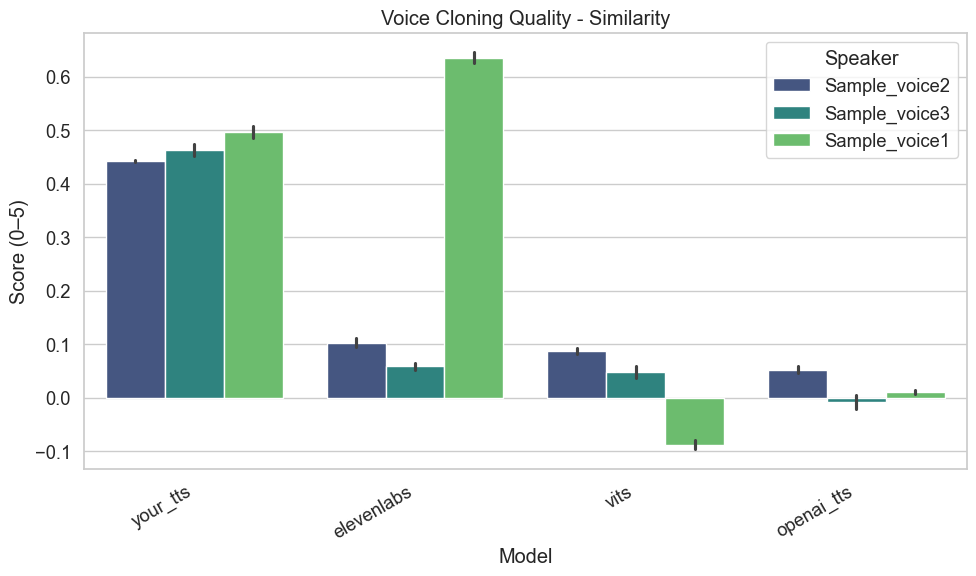

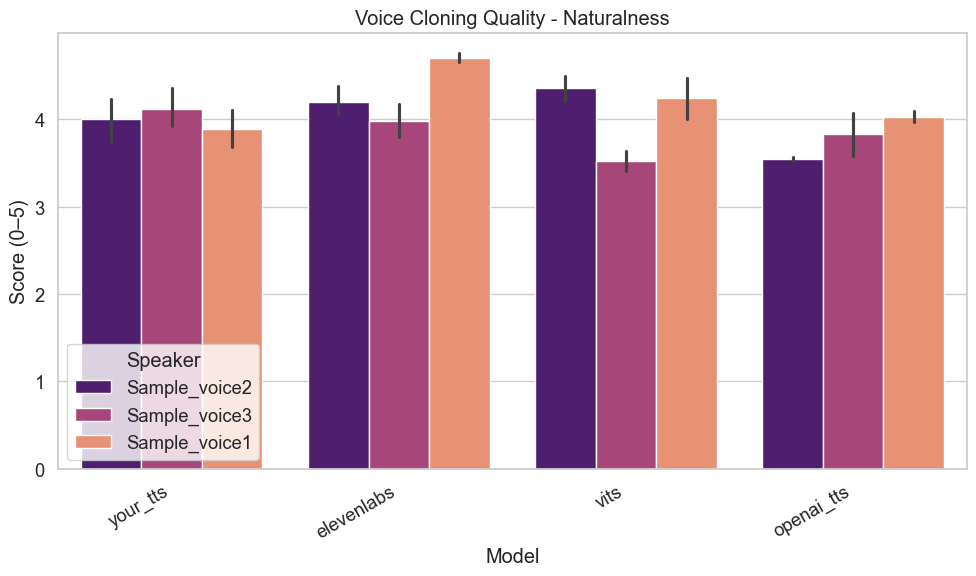

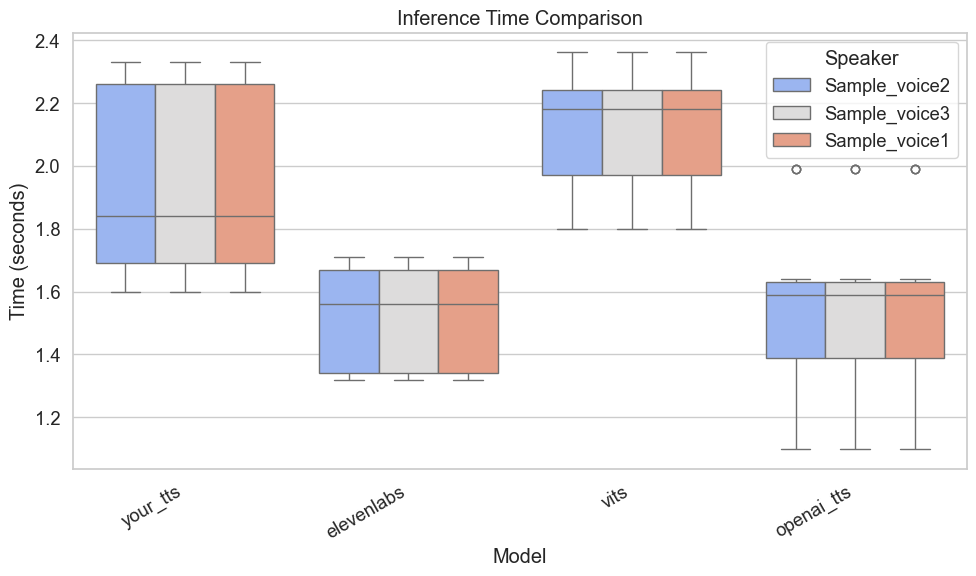

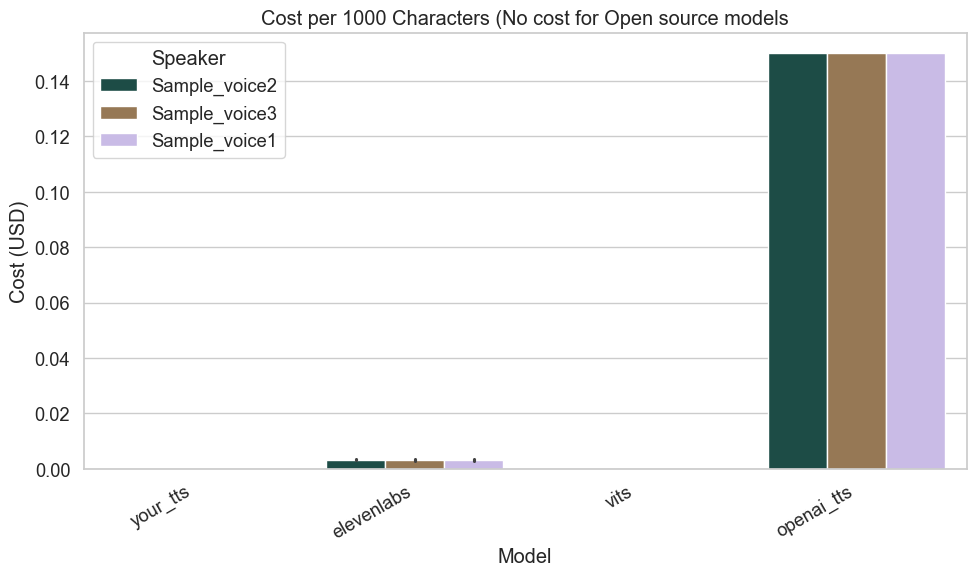

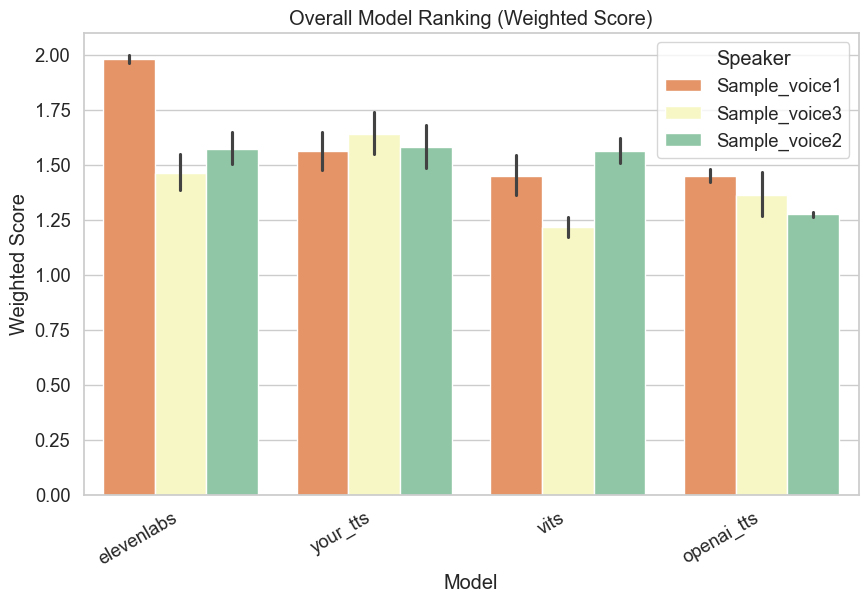

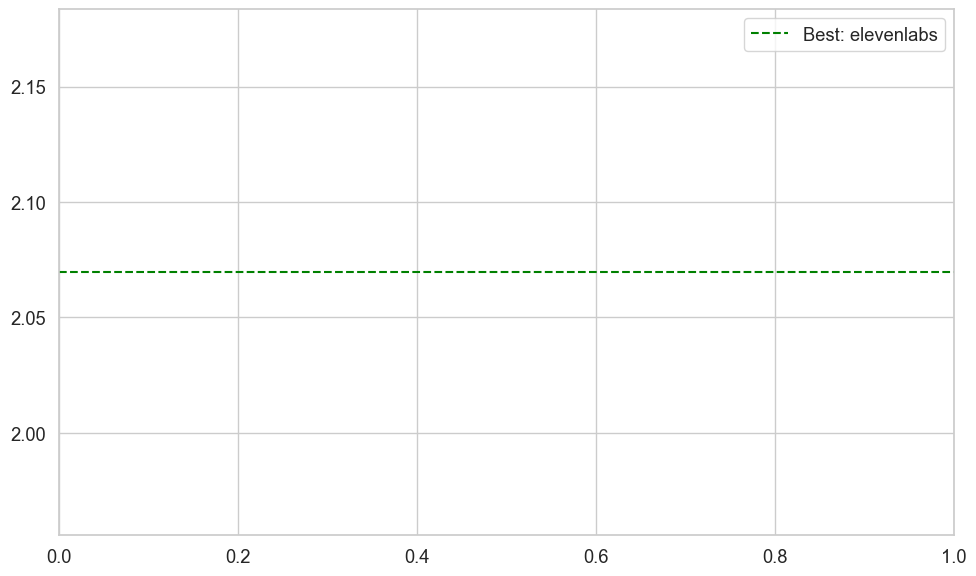

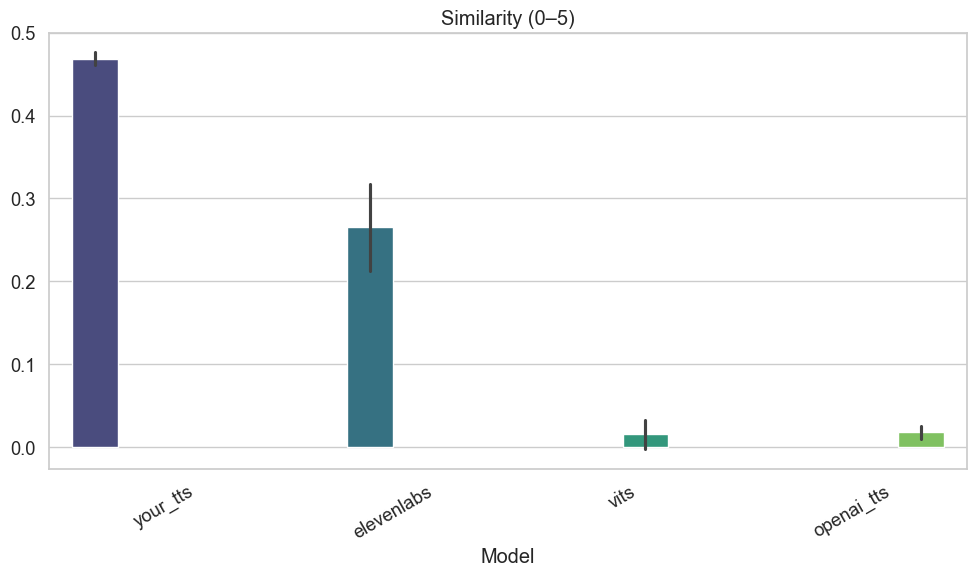

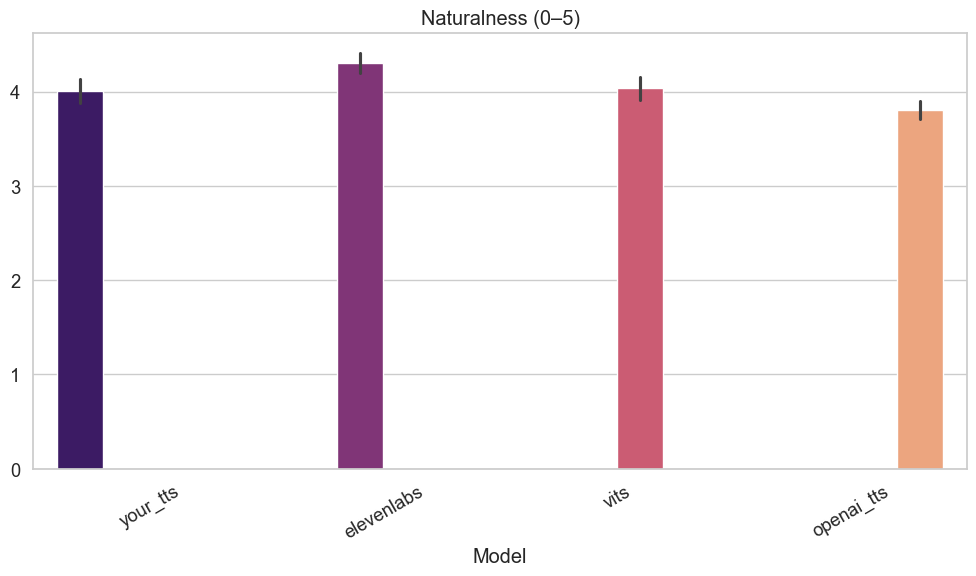

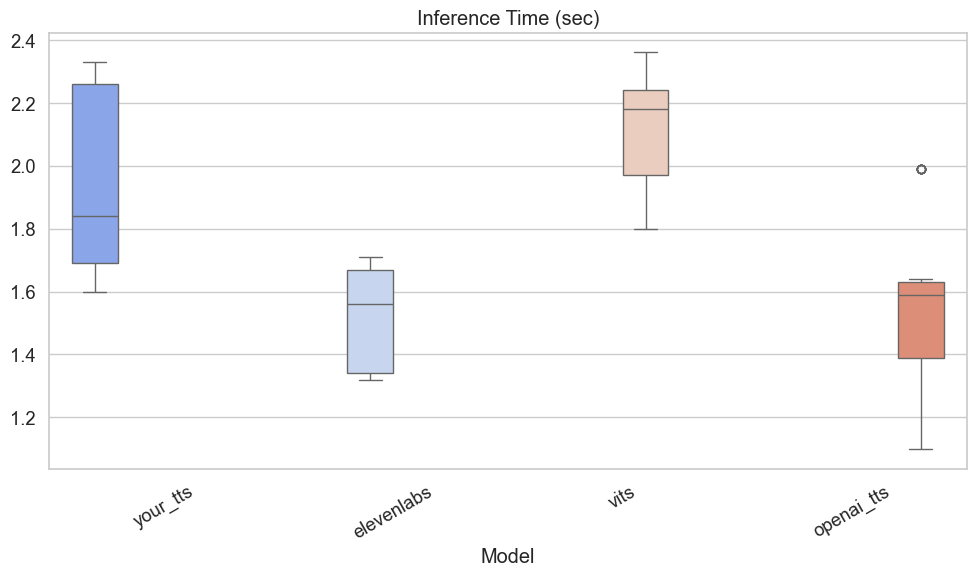

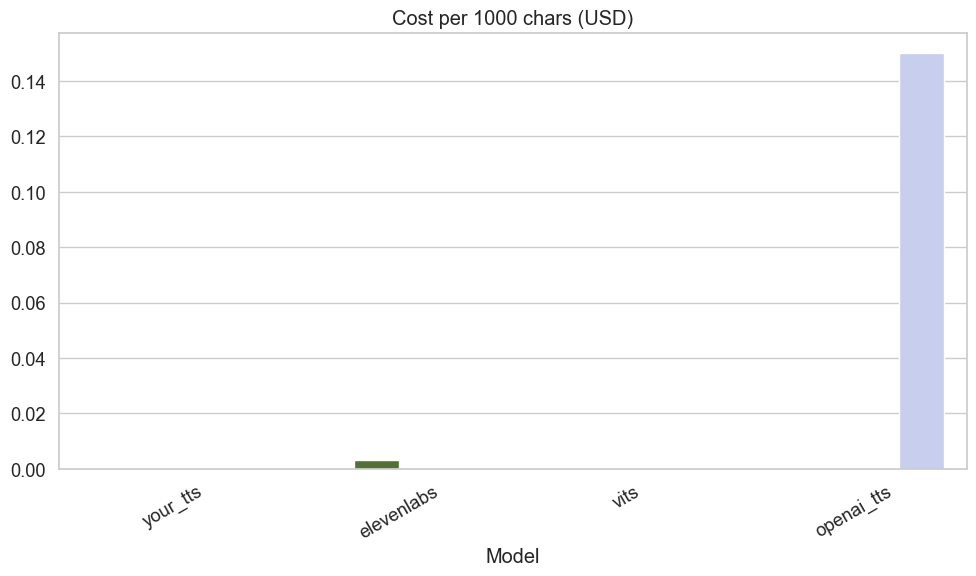

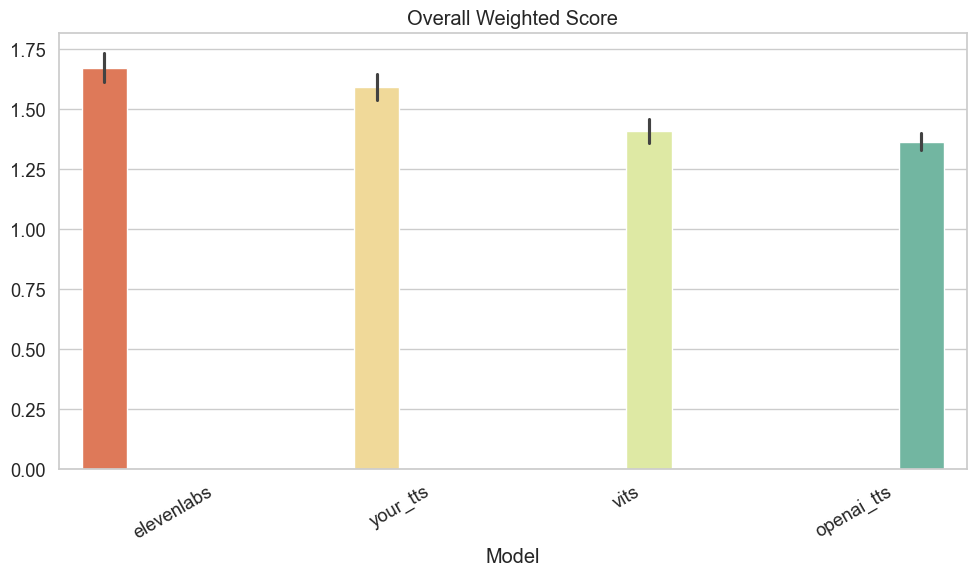

<Figure size 1000x600 with 0 Axes>

All plots + ranking saved in plots/
 Best model: elevenlabs


In [50]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load results
quality_df = pd.read_csv("voice_cloning_quality_results.csv")#Speaker,Model,Page,Similarity,Naturalness

benchmark_df = pd.read_csv("benchmark_results_multisample.csv") #Model,Voice,Page,Time,Cost


quality_selected = quality_df[["Model", "Speaker","Similarity", "Naturalness"]]
benchmark_selected = benchmark_df[["Model", "Time","Cost"]]

# Merge on 'Model'
df = pd.merge(quality_selected, benchmark_selected, on="Model")
print(df)

# Create output folder
os.makedirs("plots", exist_ok=True)

# Style
sns.set_theme(style="whitegrid", font_scale=1.2)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["savefig.dpi"] = 300

# --- Add Weighted Score ---
df["Score"] = (
    0.4 * df["Similarity"] +
    0.4 * df["Naturalness"] -
    0.1 * df["Time"] -
    0.1 * df["Cost"]
)

print(df["Score"])

df_sorted = df.sort_values(by="Score", ascending=False)
best_model = df_sorted.iloc[0]["Model"]

#--- 1. Similarity ---
plt.figure()
sns.barplot(x="Model", y="Similarity", data=df, palette="viridis", hue="Speaker" , dodge= True)
plt.title("Voice Cloning Quality - Similarity")
plt.ylabel("Score (0–5)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("plots/Similarity.png")
plt.show(block=True)

# --- 2. Naturalness ---
plt.figure()
sns.barplot(x="Model", y="Naturalness", data=df, palette="magma", hue="Speaker" , dodge= True)
plt.title("Voice Cloning Quality - Naturalness")
plt.ylabel("Score (0–5)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("plots/naturalness.png")
plt.show(block=True)

# --- 3. Inference Time ---
plt.figure()
sns.boxplot(x="Model", y="Time", data=df, palette="coolwarm", hue="Speaker" , dodge= True)
plt.title("Inference Time Comparison")
plt.ylabel("Time (seconds)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("plots/inference_time.png")
plt.show(block=True)

# --- 4. Cost ---
plt.figure()
sns.barplot(x="Model", y="Cost", data=df, palette="cubehelix", hue="Speaker" , dodge= True)
plt.title("Cost per 1000 Characters (No cost for Open source models")
plt.ylabel("Cost (USD)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("plots/cost.png")
plt.show(block=True)

# --- 5. Weighted Score Ranking ---
plt.figure()
sns.barplot(x="Model", y="Score", data=df_sorted, palette="Spectral", hue="Speaker" , dodge= True)
plt.title("Overall Model Ranking (Weighted Score)")
plt.ylabel("Weighted Score")
plt.xticks(rotation=30, ha="right")
plt.show(block=True)

# Highlight best model
plt.figure()
plt.axhline(df_sorted.iloc[0]["Score"], ls="--", color="green", label=f"Best: {best_model}")
plt.legend()
plt.tight_layout()
plt.savefig("plots/overall_score.png")
plt.show(block=True)

# --- 6. Combined Summary ---
# Similarity
plt.figure(figsize=(10,6))
sns.barplot(x="Model", y="Similarity", data=df, palette="viridis", hue="Model", dodge=True, legend=False)
plt.title("Similarity (0–5)")
plt.ylabel("")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Naturalness
plt.figure(figsize=(10,6))
sns.barplot(x="Model", y="Naturalness", data=df, palette="magma", hue="Model", dodge=True, legend=False)
plt.title("Naturalness (0–5)")
plt.ylabel("")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Inference Time
plt.figure(figsize=(10,6))
sns.boxplot(x="Model", y="Time", data=df, palette="coolwarm", hue="Model", dodge=True, legend=False)
plt.title("Inference Time (sec)")
plt.ylabel("")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Cost
plt.figure(figsize=(10,6))
sns.barplot(x="Model", y="Cost", data=df, palette="cubehelix", hue="Model", dodge=True, legend=False)
plt.title("Cost per 1000 chars (USD)")
plt.ylabel("")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Overall Weighted Score
plt.figure(figsize=(10,6))
sns.barplot(x="Model", y="Score", data=df_sorted, palette="Spectral", hue="Model", dodge=True, legend=False)
plt.title("Overall Weighted Score")
plt.ylabel("")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# Add conclusion text
conclusion = f"""
Conclusion:
- {best_model} achieved the highest overall score based on similarity, naturalness, time, and cost.
- Open-source models are cost-efficient but slower.
- Industry APIs (OpenAI, ElevenLabs) generally provide higher naturalness and faster inference.
- Trade-off exists between cost vs. quality. {best_model} offers the best balance.
"""

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("plots/summary.png", dpi=300)
plt.show(block=True)

print("All plots + ranking saved in plots/")
print(f" Best model: {best_model}")


## Conclusion

### Automated based on results

In [53]:
conclusion = f"""
Conclusion:
- {best_model} achieved the highest overall score based on similarity, naturalness, time, and cost.
- Open-source models are cost-efficient but slower.
- Industry APIs (OpenAI, ElevenLabs) generally provide higher naturalness and faster inference.
- Trade-off exists between cost vs. quality. {best_model} offers the best balance.
"""
print(conclusion)
print("All plots + ranking saved in plots/")
print(f" Best model: {best_model}")


Conclusion:
- elevenlabs achieved the highest overall score based on similarity, naturalness, time, and cost.
- Open-source models are cost-efficient but slower.
- Industry APIs (OpenAI, ElevenLabs) generally provide higher naturalness and faster inference.
- Trade-off exists between cost vs. quality. elevenlabs offers the best balance.

All plots + ranking saved in plots/
 Best model: elevenlabs


### Manual conclusion

### Conclusion

##### The voice cloning benchmark revealed several key insights about the performance and usability of different models:

#### Open-Source Models (Your_TTS, VITS):

These models provide good voice cloning quality when multiple sample files per speaker are used.
They are cost-effective and allow flexible multi-speaker cloning.
The inference time is slightly higher compared to industry APIs, but they are fully under our control and can be scaled locally.

#### Industry Models (ElevenLabs, OpenAI TTS, Azure TTS):

ElevenLabs demonstrates very high-quality voice cloning and naturalness, producing near-human results.
OpenAI and Azure TTS also deliver reliable output with consistent quality.

However, when cloning multiple voices and generating a full audiobook with conversational details, the cost rises significantly, especially for models like ElevenLabs.Despite their efficiency and speed, scaling up to multiple voices or long-form content can become expensive, making open-source models preferable for projects requiring many speakers or extended audio.

#### Overall Recommendation:

For high-quality single-voice cloning, industry models like ElevenLabs are ideal.

For multi-speaker audiobooks or budget-conscious scenarios, open-source TTS models like Your_TTS and VITS offer a practical balance between quality, flexibility, and cost.

Combining open-source models for bulk content and industry models for premium segments could be a hybrid strategy for audiobook production.

## Executive Summary: Voice Cloning Benchmark


This project evaluated multiple voice cloning models—including open-source (Your_TTS, VITS) and industry APIs (ElevenLabs, OpenAI, Azure TTS)—to determine their suitability for audiobook generation from multiple sample voices.

#### Key Findings:

**Voice Cloning Quality**: ElevenLabs delivers the most natural and human-like output, closely followed by OpenAI TTS. Open-source models provide good quality, especially when multiple voice samples per speaker are used.
Performance & Time: Industry APIs are faster in generating audio, while open-source models take slightly longer but offer full local control.

**Cost**: Open-source models are free to use, whereas industry models incur costs that scale with the number of voices and length of content. For multi-voice audiobooks, costs can become substantial.

**Scalability**: Open-source models allow cloning of many voices without cost constraints, making them more suitable for large-scale audiobook production. Industry models are ideal for high-quality, single-voice segments.

### Conclusion:

**Optimal Strategy**: Use industry models like ElevenLabs for high-quality single-voice segments. Use open-source models for bulk content or multi-speaker audiobooks to balance quality, cost, and scalability.

**Trade-offs**: ElevenLabs is efficient and produces high-quality results, but cloning multiple voices for long-form content can be expensive. Open-source models offer flexibility and cost-efficiency but slightly lower naturalness.

This study provides a framework for selecting voice cloning solutions based on project goals, balancing quality, cost, and scalability.